In [12]:
import librosa
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

In [13]:
AUDIO_PATH = "breathing.mp3"
y, sr = librosa.load(AUDIO_PATH, sr=None)

In [14]:
frame_size = 1024
hop_length = 256
amplitude_envelope = []

for i in range(0, len(y), hop_length):
    frame = y[i:i+frame_size]
    amplitude_envelope.append(max(frame))

amplitude_envelope = np.array(amplitude_envelope)
amplitude_envelope

array([0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 2.3133121e-04,
       2.3133121e-04, 1.4265818e-05], shape=(10512,), dtype=float32)

In [16]:
window_size = 10
smooth = np.convolve(amplitude_envelope, np.ones(window_size)/window_size, mode='same')

peaks, _ = find_peaks(
    smooth,
    distance=sr / hop_length * 1.5,  # minimum time between breaths (~1.5 sec)
    prominence=0.02
)


===== RESULTS =====
Breath count: 18 61.02204081632653
Breaths per minute (BPM): 17.698523116438356


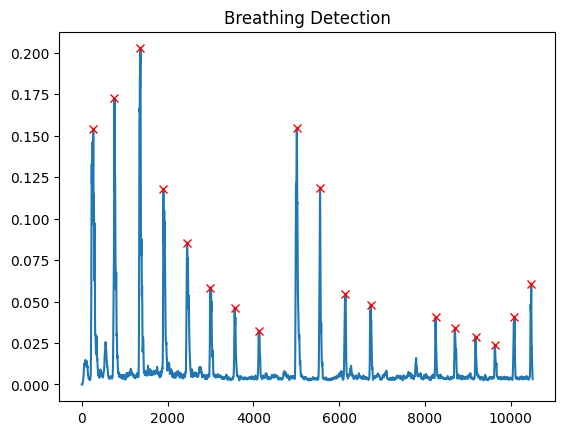

In [18]:
duration_sec = len(y) / sr
breath_count = len(peaks)

bpm = (breath_count / duration_sec) * 60

print("\n===== RESULTS =====")
print("Breath count:", breath_count, duration_sec)
print("Breaths per minute (BPM):", bpm)

# =========================
# OPTIONAL: PLOT
# =========================
plt.plot(smooth)
plt.plot(peaks, smooth[peaks], "rx")
plt.title("Breathing Detection")
plt.show()